<a href="https://colab.research.google.com/github/Aaguilar123/Macro-Liquidity-Asset-Leaderboard-Forecast/blob/Aaguilar123-patch-1/shared_eda/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Exploration, Preparation, and Feature Engineering for Liquidity Analysis

##Data Preparation and Cleaning for Merging


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 6)

df_volume = pd.read_csv('market_volume.csv', index_col='Date', parse_dates=True)
df_macro = pd.read_csv('macro_indicators.csv', index_col='Date', parse_dates=True)

print("DATA QUALITY SUMMARY")
print(f"Time Span: {df_volume.index.min().date()} to {df_volume.index.max().date()}")
print(f"Frequency: Daily (Business Days)")
print(f"Missing Values (Volume):\n{df_volume.isnull().sum()}")
print(f"\nMissing Values (Macro):\n{df_macro.isnull().sum()}")

df_volume.head()

DATA QUALITY SUMMARY
Time Span: 2015-01-01 to 2026-04-14
Frequency: Daily (Business Days)
Missing Values (Volume):
BTC-USD    0
GLD        1
QQQ        1
UUP        1
XLP        1
dtype: int64

Missing Values (Macro):
Fed_Rate             0
CPI_Inflation        1
Unemployment_Rate    1
dtype: int64


,BTC-USD,GLD,QQQ,UUP,XLP
Date,,,,,
2015-01-01,8036550,NaN,NaN,NaN,NaN
2015-01-02,7860650,8.110632e+08,2.964399e+09,3.816104e+07,2.730110e+08
2015-01-03,33054400,8.110632e+08,2.964399e+09,3.816104e+07,2.730110e+08
2015-01-04,55629100,8.110632e+08,2.964399e+09,3.816104e+07,2.730110e+08
2015-01-05,43962800,9.469429e+08,3.406577e+09,5.784806e+07,2.946172e+08


## Preprocessing & Outlier Mitigation

In [2]:
df_macro['CPI_Inflation'] = df_macro['CPI_Inflation'].pct_change(1, fill_method=None) * 100

vol_cols = ['QQQ', 'XLP', 'GLD', 'BTC-USD', 'UUP']

df_master = df_volume[vol_cols].join(df_macro, how='left')
# THE WEEKEND FIX: Drop Saturdays (5) and Sundays (6)
df_master = df_master[df_master.index.dayofweek < 5]

df_master = df_master.ffill()
df_master[vol_cols] = df_master[vol_cols].rolling(window=21).mean()

def winsorize(series, lower=0.01, upper=0.99):
    return series.clip(series.quantile(lower), series.quantile(upper))

for col in vol_cols:
    df_master[col] = winsorize(df_master[col])

# Drop the initial 21 NaN rows created by the rolling window
df_master.dropna(inplace=True)

print(f"Total observations (Trading Days Only): {len(df_master)}")
df_master.describe().round(2)

Total observations (Trading Days Only): 2880


,QQQ,XLP,GLD,BTC-USD,UUP,Fed_Rate,CPI_Inflation,Unemployment_Rate
count,2.880000e+03,2.880000e+03,2.880000e+03,2.880000e+03,2.880000e+03,2880.00,2880.00,2880.00
mean,1.254386e+10,7.237676e+08,1.634799e+09,2.513878e+10,3.555308e+07,2.08,0.25,4.63
std,9.094777e+09,3.152646e+08,1.362542e+09,2.209194e+10,2.368101e+07,1.91,0.25,1.69
min,1.987878e+09,2.145081e+08,5.421626e+08,2.144982e+07,9.062825e+06,0.05,-0.79,3.50
25%,4.681762e+09,5.139978e+08,9.071480e+08,4.254718e+09,2.004463e+07,0.33,0.10,3.70
50%,1.114534e+10,6.593364e+08,1.228160e+09,2.330361e+10,2.779854e+07,1.55,0.23,4.20
75%,1.801497e+10,8.578291e+08,1.718809e+09,3.848153e+10,4.153870e+07,4.10,0.38,4.90
max,4.084482e+10,1.982796e+09,9.027753e+09,8.211170e+10,1.243231e+08,5.33,1.26,14.80


Refactor preprocessing pipeline for strict business day alignment

- Macro transformation:
  - Converted CPI index to % change prior to merge.
- Data integration:
  - Joined volume and macro data.
  - Dropped weekends to enforce a strict US trading calendar.
  - Forward-filled missing holiday/macro data.
- Volume smoothing:
  - Applied 21-day rolling mean (now exactly 1 trading month).
- Outlier handling:
  - Winsorized volume series (1% lower, 99% upper) to cap spikes.
- Target engineering & cleanup:
  - Shifted 63 rows forward (exactly 1 fiscal quarter) for 3M Log-RVOL.
  - Dropped trailing NaNs to finalize the clean dataset.

## Exploration of Trends & Seasonality

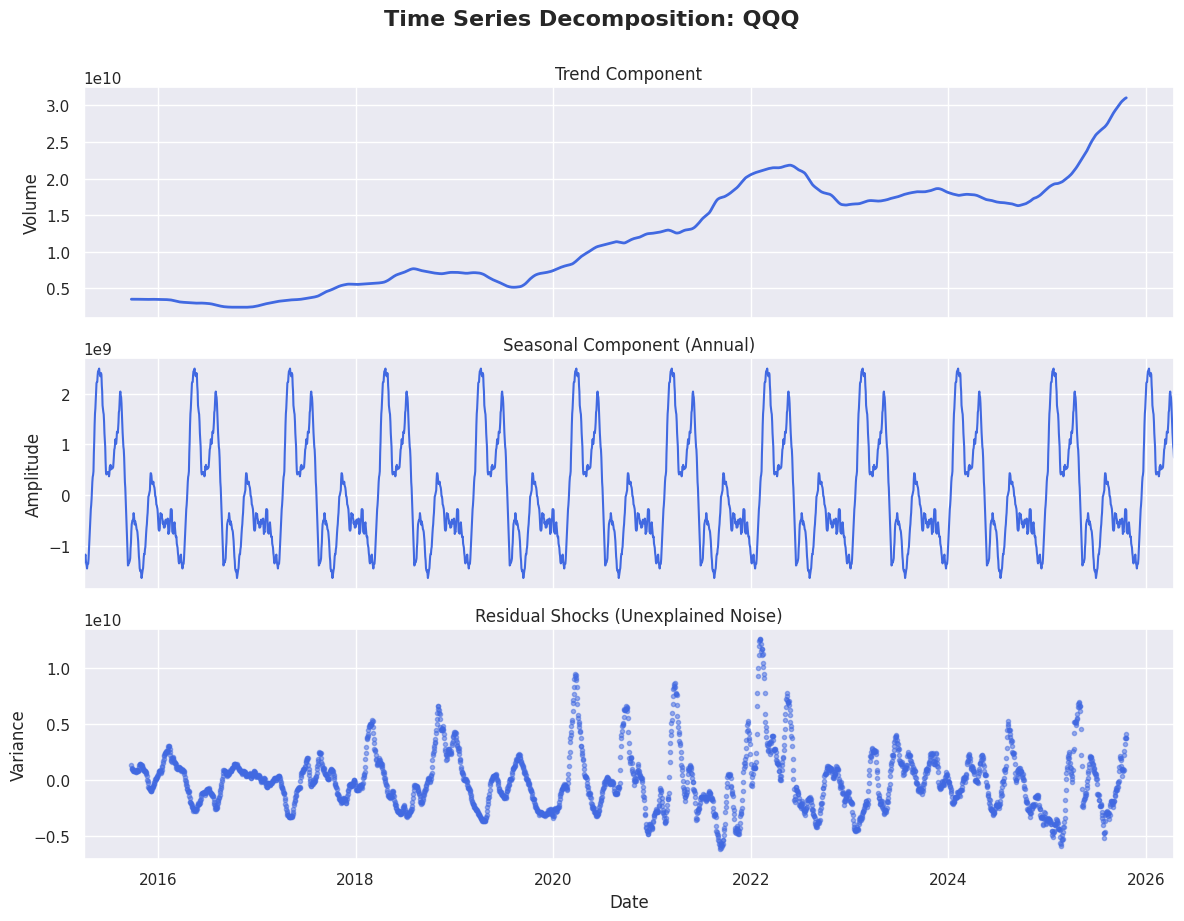

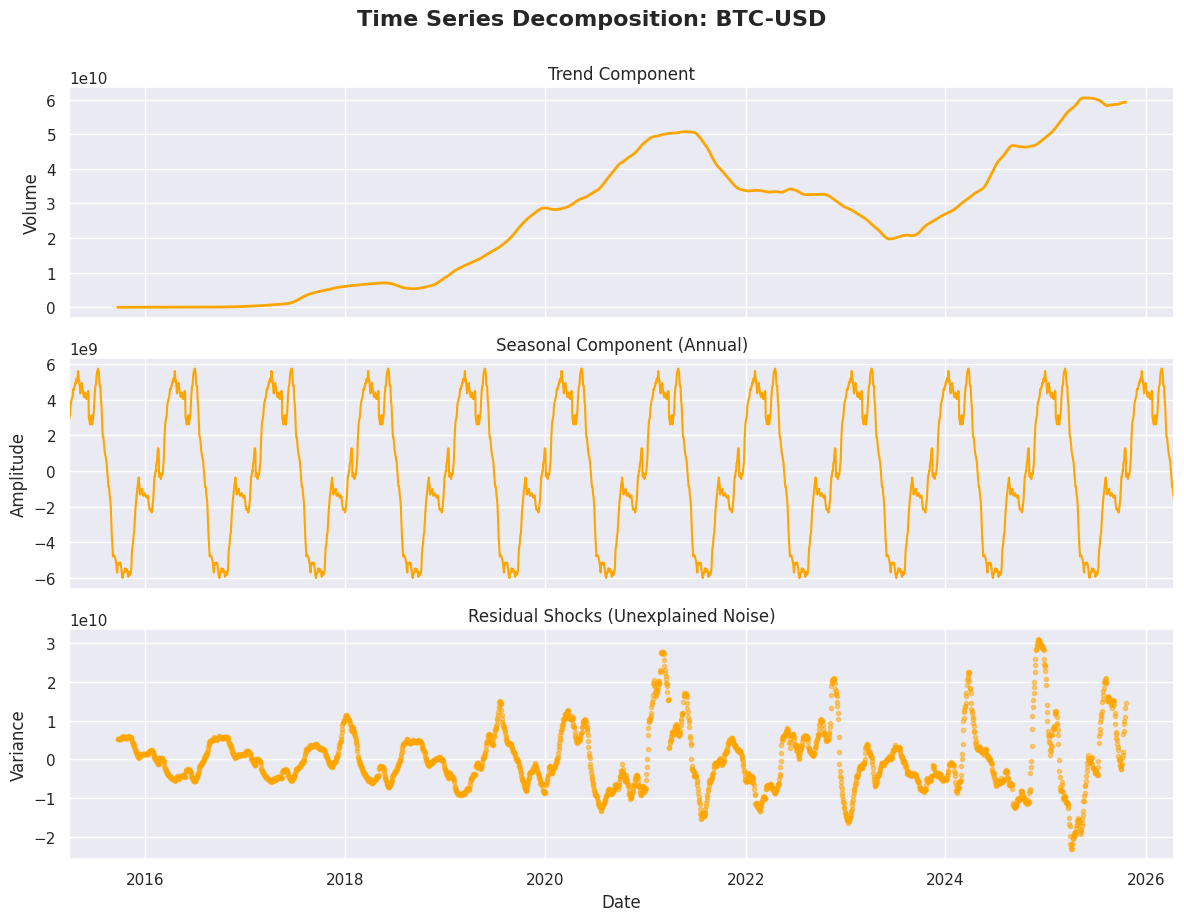

In [3]:
assets_to_compare = ['QQQ', 'BTC-USD']

for asset in assets_to_compare:
    line_color = 'orange' if asset == 'BTC-USD' else 'royalblue'

    res = seasonal_decompose(df_master[asset], model='additive', period=252)

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f'Time Series Decomposition: {asset}', fontsize=16, fontweight='bold', y=0.95)

    res.trend.plot(ax=ax1, title=f'Trend Component', color=line_color, linewidth=2)
    ax1.set_ylabel('Volume')

    res.seasonal.plot(ax=ax2, title=f'Seasonal Component (Annual)', color=line_color, linewidth=1.5)
    ax2.set_ylabel('Amplitude')

    res.resid.plot(ax=ax3, title=f'Residual Shocks (Unexplained Noise)', color=line_color, style='.', alpha=0.5)
    ax3.set_ylabel('Variance')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

Compare volume dynamics of QQQ (structural) vs BTC (speculative)

- Trend:
  - QQQ shows smooth, steady growth with mild drawdowns (e.g., 2020, 2022)
  - BTC shows sharp expansions and contractions, indicating high volatility

- Seasonality:
  - Both exhibit annual seasonality (period=252 trading days)
  - QQQ seasonality is stable and consistent
  - BTC seasonality is stronger and more erratic

- Residuals (shocks):
  - QQQ has relatively small, controlled residual noise
  - BTC shows large, clustered shocks (especially 2020–2022)

Focus:
- QQQ behaves like a stable, institution-driven asset
- BTC behaves like a speculative, sentiment-driven asset with higher volatility

## Defining Forecasting Goals & Multi-Horizon Targets

In [4]:
target_columns_3m = []
horizon_days = 63

for col in vol_cols:
    target_name = f"{col}_Target_RVOL_3M"

    future_vol = df_master[col].shift(-horizon_days)
    current_vol = df_master[col]

    raw_target = np.log(future_vol / current_vol) * 100
    df_master[target_name] = raw_target.rolling(window=5).mean()
    target_columns_3m.append(target_name)

df_master.dropna(inplace=True)

# CSV
features = vol_cols + ['Fed_Rate', 'CPI_Inflation', 'Unemployment_Rate']
export_cols = features + target_columns_3m

df_master[export_cols].to_csv('final_engineered_data.csv')
print("CSV Exported. Contains ONLY Machine Learning Features and 3M Targets.")
final = pd.read_csv('final_engineered_data.csv', index_col='Date', parse_dates=True)
print(final.head())

CSV Exported. Contains ONLY Machine Learning Features and 3M Targets.
                     QQQ           XLP           GLD       BTC-USD  \
Date                                                                 
2015-04-07  2.847844e+09  3.742496e+08  6.298564e+08  3.024707e+07   
2015-04-08  2.810426e+09  3.694404e+08  6.232301e+08  2.845257e+07   
2015-04-09  2.802109e+09  3.631228e+08  6.143870e+08  2.786589e+07   
2015-04-10  2.783797e+09  3.542146e+08  6.011394e+08  2.768954e+07   
2015-04-13  2.673849e+09  3.508012e+08  5.945662e+08  2.767813e+07   

                     UUP  Fed_Rate  CPI_Inflation  Unemployment_Rate  \
Date                                                                   
2015-04-07  6.956162e+07      0.12       0.104248                5.4   
2015-04-08  6.677084e+07      0.12       0.104248                5.4   
2015-04-09  6.870450e+07      0.12       0.104248                5.4   
2015-04-10  6.827035e+07      0.12       0.104248                5.4   
2015-04

A 3-month (63 trading days) horizon was selected based on EDA below. The target is defined as the log percentage change in volume (RVOL -> Relative Volume), which ensures symmetry and reduces the impact of extreme values common in financial data. A 5-day rolling mean is applied to the target to smooth short-term noise and improve model stability while preserving the underlying macro signal.

## Explanatory Data Analysis

### Macro Regime Sensitivity (Heatmaps)


 Dynamically calculating EDA variables (Regimes, 1M, 6M)...


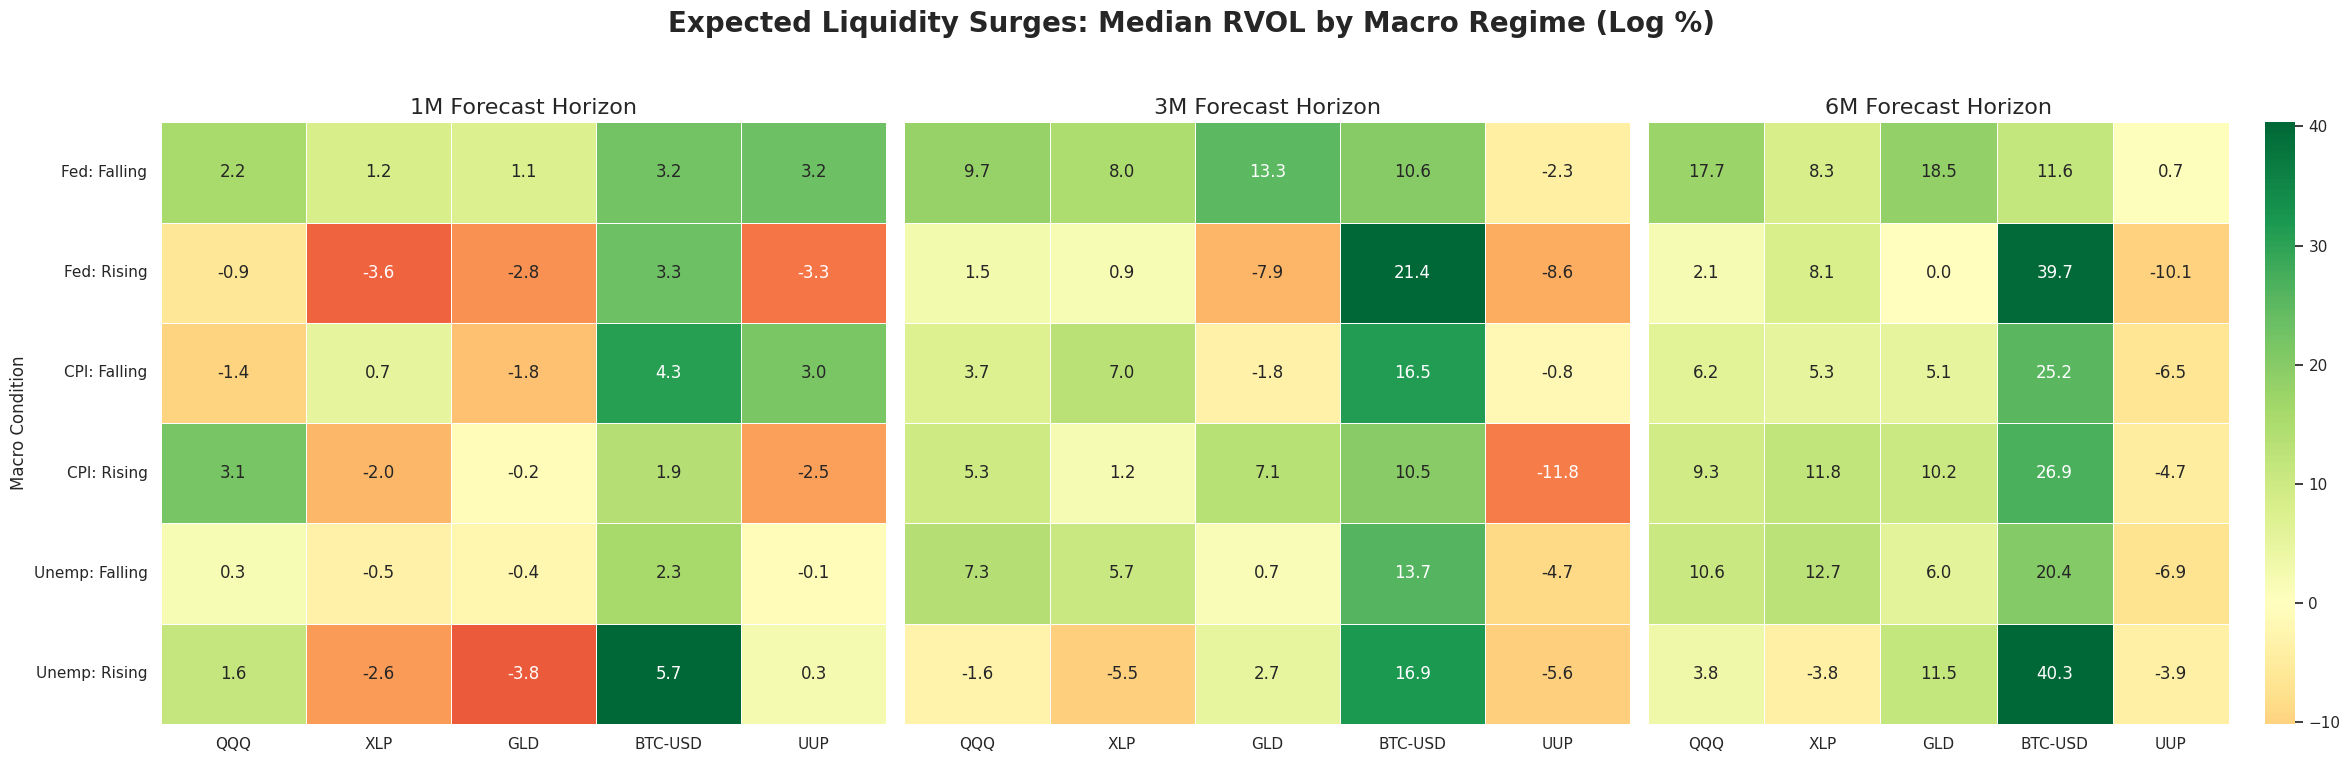

In [5]:
print("\n Dynamically calculating EDA variables (Regimes, 1M, 6M)...")

df_master['Fed_State'] = np.where(df_master['Fed_Rate'].diff(60) > 0, 'Fed: Rising', 'Fed: Falling')
df_master['CPI_State'] = np.where(df_master['CPI_Inflation'].diff(60) > 0, 'CPI: Rising', 'CPI: Falling')
df_master['Unemp_State'] = np.where(df_master['Unemployment_Rate'].diff(60) > 0, 'Unemp: Rising', 'Unemp: Falling')

eda_targets = target_columns_3m.copy()
eda_horizons = {'1M': 21, '6M': 126}

for label, h_days in eda_horizons.items():
    for col in vol_cols:
        t_name = f"{col}_Target_RVOL_{label}"
        raw_t = np.log(df_master[col].shift(-h_days) / df_master[col]) * 100
        df_master[t_name] = raw_t.rolling(window=5).mean()
        eda_targets.append(t_name)

# Heatmaps
def plot_macro_heatmaps(df, targets):
    fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)
    fig.suptitle('Expected Liquidity Surges: Median RVOL by Macro Regime (Log %)', fontsize=20, fontweight='bold')

    for i, label in enumerate(['1M', '3M', '6M']):
        hz_cols = [c for c in targets if label in c]
        agg_data = pd.concat([
            df.groupby('Fed_State')[hz_cols].median(),
            df.groupby('CPI_State')[hz_cols].median(),
            df.groupby('Unemp_State')[hz_cols].median()
        ])
        agg_data.columns = [c.replace(f'_Target_RVOL_{label}', '') for c in agg_data.columns]
        sns.heatmap(agg_data, annot=True, cmap='RdYlGn', center=0, fmt=".1f", linewidths=.5, ax=axes[i], cbar=(i==2))
        axes[i].set_title(f'{label} Forecast Horizon', fontsize=16)
        if i == 0: axes[i].set_ylabel('Macro Condition', fontsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_macro_heatmaps(df_master, eda_targets)

### Macro Regime Analysis — Expected Liquidity Surges  

The heatmaps show median forward RVOL (log %) across macro regimes (Fed, CPI, Unemployment) for 1M, 3M, and 6M horizons.  

Overall, the results confirm that **liquidity responses are regime-dependent and non-linear**, with clearer and more persistent patterns emerging at longer horizons.  

- **1M Horizon:**  
  Signals remain noisy and inconsistent, with frequent sign changes across assets and regimes.  
  Short-term liquidity dynamics are dominated by idiosyncratic flows and microstructure noise, limiting macro interpretability.  

- **3M Horizon:**  
  Clear structure emerges, particularly:  
  - **BTC shows consistently strong positive RVOL across most regimes**, especially under rising unemployment and inflation, indicating its role as the primary high-beta liquidity target.  
  - **QQQ shows relatively stable moderate growth, while XLP remains more regime-dependent with mixed responses**, reflecting differences between broad equity exposure and defensive positioning.  
  - **GLD shows inconsistent short-term behavior**, while **UUP exhibits mostly weak or negative responses**, indicating conditional macro positioning rather than persistent flows.  

- **6M Horizon:**  
  Signals become **stronger and more persistent**, with:  
  - **BTC dominating across nearly all regimes**, showing the largest and most consistent liquidity surges.  
  - **QQQ, XLP, and GLD turning broadly positive**, indicating delayed but wider participation across assets.  
  - **UUP remaining selective and often negative**, reinforcing its role as a conditional macro vehicle.  

---  

A 3-month (63 trading days) horizon was selected based on EDA, as it provides the optimal balance between short-term noise (1M) and longer-term lag (6M), capturing macro-driven liquidity shifts with clearer timing and interpretability.

### Variance & Outlier Distribution (Boxplots)


 MACRO-CONDITIONED DISTRIBUTION ANALYSIS (Log-RVOL)


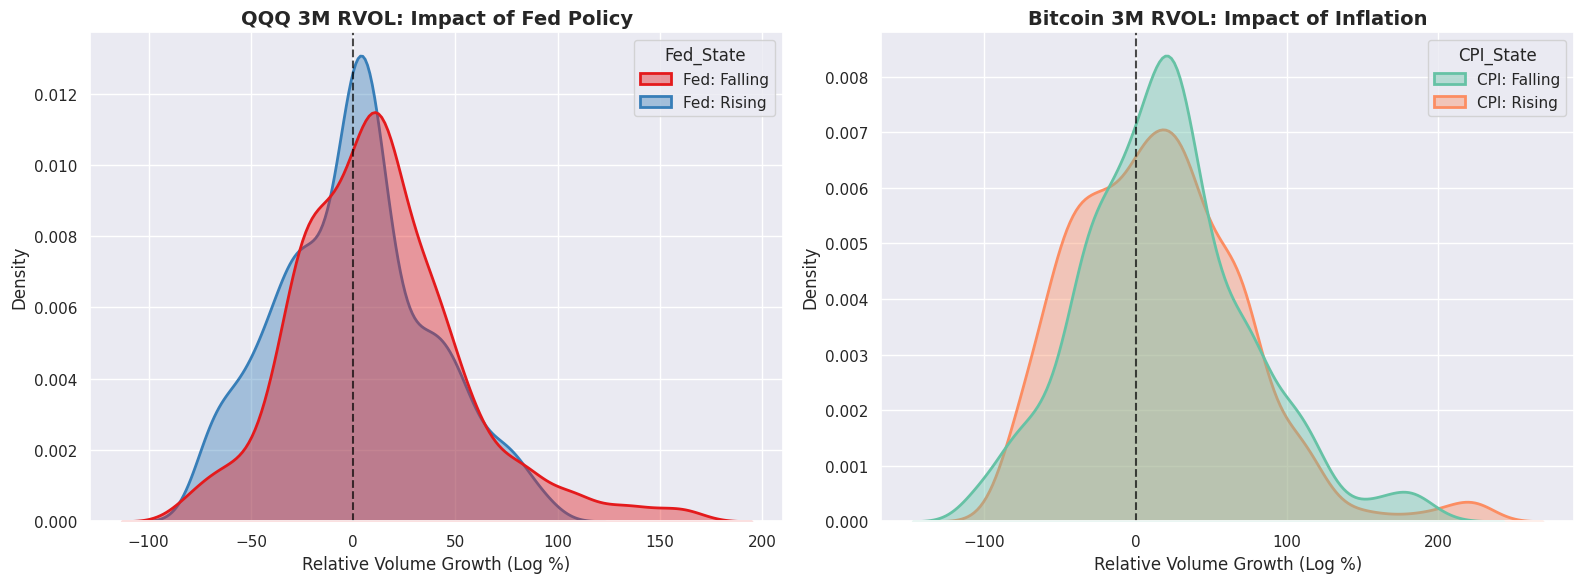


 OUTLIER DIAGNOSTIC: Cross-Asset Variance


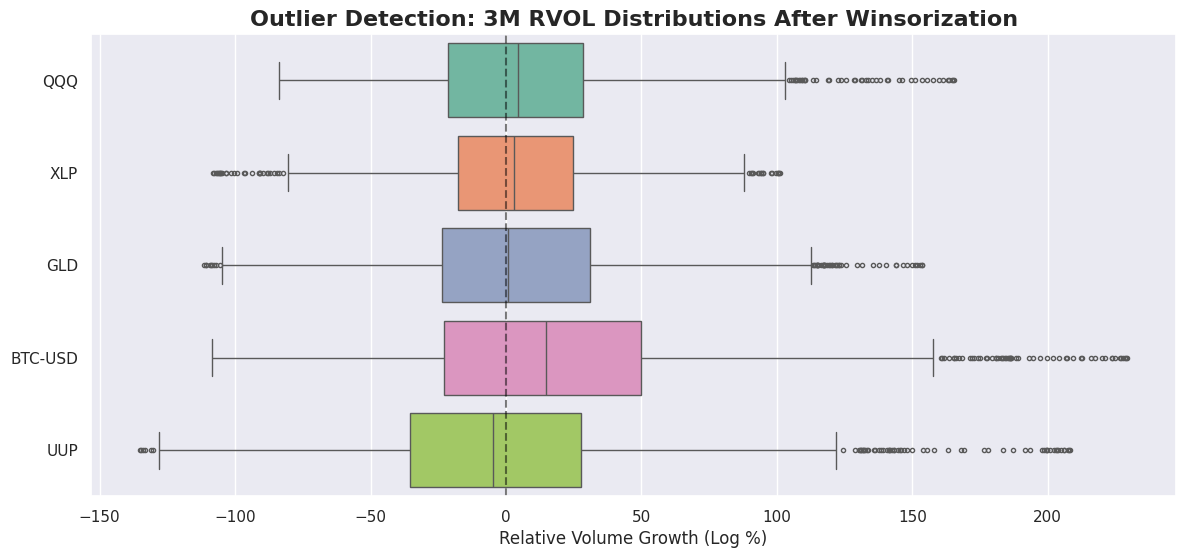

In [6]:
print("\n MACRO-CONDITIONED DISTRIBUTION ANALYSIS (Log-RVOL)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(data=df_master, x='QQQ_Target_RVOL_3M', hue='Fed_State',
            fill=True, common_norm=False, alpha=0.4, ax=axes[0], palette='Set1', linewidth=2)
axes[0].set_title('QQQ 3M RVOL: Impact of Fed Policy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Relative Volume Growth (Log %)')
axes[0].axvline(0, color='black', linestyle='--', alpha=0.7)


sns.kdeplot(data=df_master, x='BTC-USD_Target_RVOL_3M', hue='CPI_State',
            fill=True, common_norm=False, alpha=0.4, ax=axes[1], palette='Set2', linewidth=2)
axes[1].set_title('Bitcoin 3M RVOL: Impact of Inflation', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Relative Volume Growth (Log %)')
axes[1].axvline(0, color='black', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("\n OUTLIER DIAGNOSTIC: Cross-Asset Variance")
target_3m_cols = [c for c in df_master.columns if '_Target_RVOL_3M' in c]
plt.figure(figsize=(14, 6))

sns.boxplot(data=df_master[target_3m_cols], orient="h", palette="Set2", fliersize=3)
plt.yticks(ticks=range(len(target_3m_cols)), labels=[c.replace('_Target_RVOL_3M', '') for c in target_3m_cols])

plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Outlier Detection: 3M RVOL Distributions After Winsorization', fontsize=16, fontweight='bold')
plt.xlabel('Relative Volume Growth (Log %)', fontsize=12)
plt.show()

### Distribution & Outlier Analysis — 3M RVOL

RVOL is **skewed, fat-tailed, and regime-dependent**.

- **QQQ vs Fed:**
  Fed cuts -> distribution shifts right (higher liquidity)  
  Fed hikes -> shifts left (weaker liquidity)  
  -> clear directional sensitivity to policy

- **BTC vs CPI:**  
  Rising inflation -> fatter right tail -> higher probability of liquidity surges  

Across assets:
- BTC and UUP drive extreme upside tails
- GLD and XLP remain tighter, QQQ in between  

### Key Insight

Liquidity is **non-linear and concentrated in tails**:  
macro regimes shift *where* extremes occur, not averages  

-> Requires **asset-specific, non-linear individual modeling**

### Feature Sensitivity & Momentum

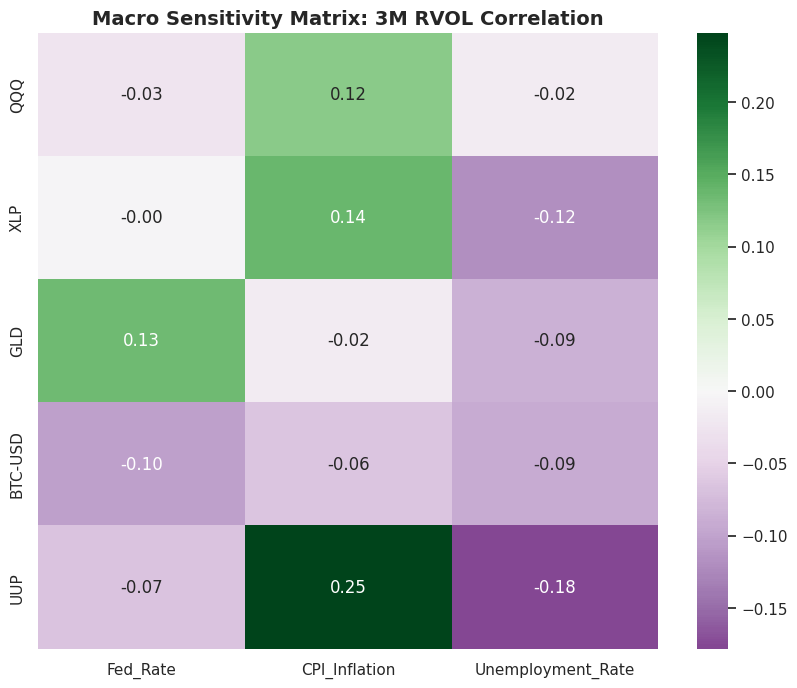

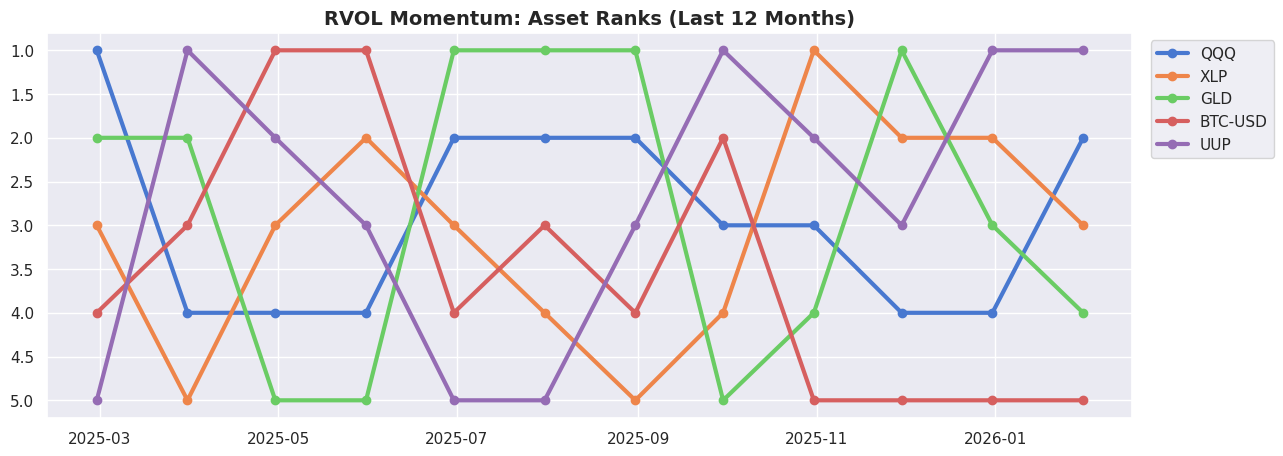

In [7]:
# Sensitivity Matrix (Correlation)
macro_vars = ['Fed_Rate', 'CPI_Inflation', 'Unemployment_Rate']

target_columns = df_master.columns

target_3m = [c for c in target_columns if '3M' in c]
corr_matrix = df_master[target_3m + macro_vars].corr().loc[target_3m, macro_vars]
corr_matrix.index = [c.replace('_Target_RVOL_3M', '') for c in corr_matrix.index]

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='PRGn', center=0, fmt=".2f")
plt.title('Macro Sensitivity Matrix: 3M RVOL Correlation', fontsize=14, fontweight='bold')
plt.show()

# 12-Month Momentum Leaderboard
hz_cols = [c for c in target_columns if '3M' in c]
monthly_ranks = df_master[hz_cols].resample('ME').last().rank(axis=1, ascending=False)
monthly_ranks.columns = [c.replace('_Target_RVOL_3M', '') for c in monthly_ranks.columns]

plt.figure(figsize=(14, 5))
for col in monthly_ranks.columns:
    plt.plot(monthly_ranks.index[-12:], monthly_ranks[col].tail(12), marker='o', linewidth=3, label=col)
plt.gca().invert_yaxis()
plt.title('RVOL Momentum: Asset Ranks (Last 12 Months)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()

### **The macro sensitivity matrix**

Shows generally weak linear correlations, but with clear asset-specific patterns, supporting the need for non-linear modeling.

- CPI Inflation emerges as the most influential variable:  
  - Strong positive relationships with UUP (0.25) and XLP (0.14)  
  - Moderate positive impact on QQQ (0.12)  
  -> Suggests inflation dynamics play a key role in driving liquidity shifts, particularly toward defensive and macro-sensitive assets  

- Fed Rate effects are mixed and relatively weak:  
  - Positive only for GLD (0.13)  
  - Slightly negative or negligible for other assets  
  -> Indicates rate changes alone do not strongly explain liquidity without broader context  

- Unemployment Rate shows consistently negative relationships across all assets:  
  - Strongest for UUP (-0.18) and XLP (-0.12)  
  -> Suggests rising labor stress is associated with reduced forward liquidity growth  


### **RVOL Momentum (12M) — Macro Narrative**

*Since rankings are based on 3-month forward RVOL, these patterns reflect realized future liquidity shifts, not immediate market reactions.*

---

Phase 1: Apr–Jun 2025 — Late Tightening / Pre-Easing Setup  
- CPI declining (~2.7% → ~2.3%)  
- Fed near peak, no cuts yet  
- Unemployment gradually rising (~4.0% → ~4.3%)  

RVOL:
- BTC rises to rank 1 (May–Jun)  
- GLD weak (4–5)  
- QQQ/XLP mid  
- UUP volatile  

Interpretation:  
Liquidity begins shifting into risk assets (BTC) ahead of easing,  
reflecting forward positioning for expected rate cuts.

---

Phase 2: Jul–Sep 2025 — Start of Easing / Regime Transition  
- CPI stabilizes (~2.5–2.8%)  
- Fed begins rate cuts (easing cycle starts)  
- Unemployment peaks (~4.4–4.5%)  

RVOL:
- BTC remains dominant (rank 1 Jul–Sep)  
- GLD also ranks high (1–2)  
- UUP weak (4–5)  
- QQQ/XLP secondary  

Interpretation:  
The start of easing does not trigger a clean risk-on move:  
- BTC = continued speculative liquidity  
- GLD = simultaneous hedge demand  

-> Market shows mixed positioning, not pure risk-on.

---

Phase 3: Oct 2025 – Feb 2026 — Inflation Repricing / Macro Rotation  
- CPI re-accelerates (~2.4% -> ~3.3%)  
- Fed slows or pauses easing due to inflation risk  
- Unemployment stabilizes (~4.3–4.4%)  

RVOL:
- BTC collapses to rank 5 (persistent)  
- XLP spikes (rank 1 in Nov)  
- GLD briefly leads (Dec)  
- UUP dominates (rank 1 Jan–Feb)  

Interpretation:  
Liquidity rotates sequentially:  
BTC (risk) -> XLP/GLD (defensive) -> UUP (macro positioning)  

-> Capital shifts toward policy-sensitive assets (USD) as inflation risk returns.

---

### Final Insight

RVOL rankings reveal a macro-driven rotation in future liquidity leadership:  
BTC (risk) -> GLD (short-term hedge) -> XLP (defensive build-up) -> UUP (macro positioning)  

QQQ remains relatively stable, acting as a structural liquidity anchor,  
while major regime shifts are expressed through BTC, GLD, XLP, and UUP.

## Statistical Diagnostic & Evaluation Setup

In [8]:
print("STATISTICAL DIAGNOSTIC: SIGNAL-TO-NOISE RATIO (SNR)")

snr_stats = df_master.groupby('Fed_State')[target_3m].agg(['median', 'std']).round(2)

snr_stats.columns = pd.MultiIndex.from_tuples([(c[0].replace('_Target_RVOL_3M', ''), c[1]) for c in snr_stats.columns])
print(snr_stats)

print("\n EVALUATION CRITERIA DEFINITION")
print("Primary Metric: Mean Absolute Error (MAE) - Robust to outlier noise.")
print("Secondary Metric: RMSE - Penalizes large forecasting misses.")
print("Validation Strategy: Chronological Time-Series Split (No random shuffling).")

STATISTICAL DIAGNOSTIC: SIGNAL-TO-NOISE RATIO (SNR)
                QQQ           XLP           GLD        BTC-USD           UUP  \
             median    std median    std median    std  median    std median   
Fed_State                                                                      
Fed: Falling   9.74  41.16   7.99  35.37  13.30  45.94   10.60  49.08  -2.29   
Fed: Rising    1.47  37.10   0.86  32.34  -7.89  37.88   21.43  60.69  -8.57   

                     
                std  
Fed_State            
Fed: Falling  57.54  
Fed: Rising   41.73  

 EVALUATION CRITERIA DEFINITION
Primary Metric: Mean Absolute Error (MAE) - Robust to outlier noise.
Secondary Metric: RMSE - Penalizes large forecasting misses.
Validation Strategy: Chronological Time-Series Split (No random shuffling).


RVOL exhibits low signal-to-noise ratios across assets, with high volatility dominating median effects, reinforcing the need for robust, non-linear, and asset-specific modeling approaches.